In [1]:
import os, sys
import numpy as np
import pandas as pd

# Lab 2
These exercises focus on Pandas. Work through all exercises, searching for help when you need to (ie. frequently).

In [2]:
import pandas as pd

__EXERCISE 1: Pie shop__

_Objective: Create and manipulate DataFrames_
* Create a DataFrame with three columns: month, apple_pie_sales, blueberry_pie_sales
* Summarize which products sold best
* Create a new column to summarize revenues

In [3]:
# YOUR CODE HERE: create the df using the data supplied

months = ['Jan','Feb', 'Mar', 'Apr']
applie_pie_sales = [34, 19, 28, 45]
blueberry_pie_sales =  [18, 6, 15, 51]

#Create the DataFrame
df = pd.DataFrame({
    'month': months,
    'apple_pie_sales': applie_pie_sales,
    'blueberry_pie_sales': blueberry_pie_sales
})

# Display the DataFrame
print("Initial DataFrame:")
print(df)

# Calculate total sales
total_apple = df['apple_pie_sales'].sum()
total_blueberry = df['blueberry_pie_sales'].sum()
if total_apple > total_blueberry:
    print("Apple pies sold best with", total_apple, "units sold.")
elif total_blueberry > total_apple:
    print("Blueberry pies sold best with", total_blueberry, "units sold.")
else:
    print("Both products sold equally well with", total_apple, "units each.")

# Create a new column to summarize revenues
apple_pie_price = 12
blueberry_pie_price = 15
df['apple_pie_revenue'] = df['apple_pie_sales']*apple_pie_price
df['blueberry_pie_revenue'] = df['blueberry_pie_sales']*blueberry_pie_price


# Display the updated DataFrame with revenues
print("\nUpdated DataFrame with total revenue:")
print(df)



Initial DataFrame:
  month  apple_pie_sales  blueberry_pie_sales
0   Jan               34                   18
1   Feb               19                    6
2   Mar               28                   15
3   Apr               45                   51
Apple pies sold best with 126 units sold.

Updated DataFrame with total revenue:
  month  apple_pie_sales  blueberry_pie_sales  apple_pie_revenue  \
0   Jan               34                   18                408   
1   Feb               19                    6                228   
2   Mar               28                   15                336   
3   Apr               45                   51                540   

   blueberry_pie_revenue  
0                    270  
1                     90  
2                    225  
3                    765  


In [4]:
# YOUR CODE HERE: calculate total sales of apple pies and total sales of blueberry pies
total_apple = df['apple_pie_sales'].sum()
total_blueberry = df['blueberry_pie_sales'].sum()

print(f"Total apple pies sold: {total_apple}")
print(f"Total blueberry pies sold: {total_blueberry}")

Total apple pies sold: 126
Total blueberry pies sold: 90


In [5]:
# YOUR CODE HERE: create a new columns entitled apple_pie_revenue and blueberry_pie_revenue

# Hint: revenue = units sold * price. Use the prices below.

apple_pie_price = 12
blueberry_pie_price = 15


df['apple_pie_revenue'] = df['apple_pie_sales'] * apple_pie_price
df['blueberry_pie_revenue'] = df['blueberry_pie_sales'] * blueberry_pie_price

# Display the updated DataFrame with revenues
print("\nUpdated DataFrame with total revenue:")
print(df)


Updated DataFrame with total revenue:
  month  apple_pie_sales  blueberry_pie_sales  apple_pie_revenue  \
0   Jan               34                   18                408   
1   Feb               19                    6                228   
2   Mar               28                   15                336   
3   Apr               45                   51                540   

   blueberry_pie_revenue  
0                    270  
1                     90  
2                    225  
3                    765  


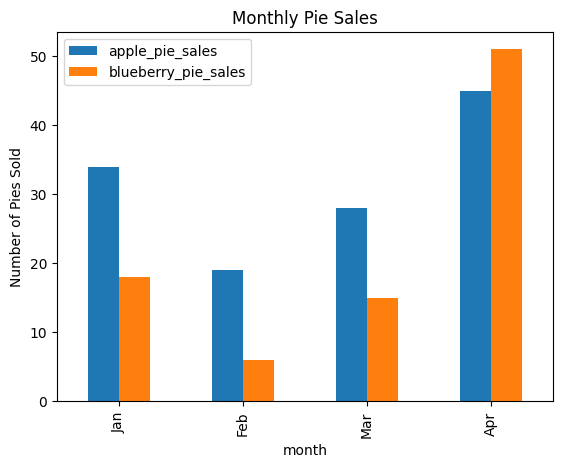

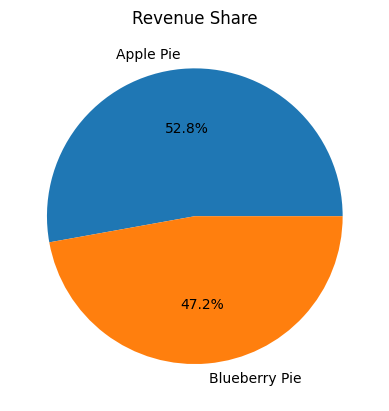

In [6]:
# BONUS: find a way to plot bar charts and pie charts (ha) of the shop's sales
import matplotlib.pyplot as plt

# Bar chart
df.plot(x='month', y=['apple_pie_sales', 'blueberry_pie_sales'], kind='bar')
plt.title('Monthly Pie Sales')
plt.ylabel('Number of Pies Sold')
plt.show()

# Pie chart
total_revenue = df['apple_pie_revenue'].sum() + df['blueberry_pie_revenue'].sum()
plt.pie([df['apple_pie_revenue'].sum(), df['blueberry_pie_revenue'].sum()], 
        labels=['Apple Pie', 'Blueberry Pie'], 
        autopct='%1.1f%%')
plt.title('Revenue Share')
plt.show()

__EXERCISE 2: NYC housing__

_Objective: clean and manipulate a real-world dataset_

We are using the PLUTO (Primary Land Use Tax Lot Output) database, which lists every building in New York City.
Source is [NYC Open Data Portal](https://www1.nyc.gov/site/planning/data-maps/open-data/dwn-pluto-mappluto.page). Check the [data dictionary](https://www1.nyc.gov/assets/planning/download/pdf/data-maps/open-data/pluto_datadictionary.pdf?r=18v2beta).

In [7]:
url = 'https://github.com/worldbank/Python-for-Data-Science/raw/master/Spring%202019%208-week%20course/week%203/pluto_shorter.csv'
df = pd.read_csv(url, low_memory=False)

__Step 1: Inspect and prepare the dataset__

In [8]:
# Use df.head() to see the first five rows. A bit messy, no?
df.head()

,Unnamed: 0,borough,block,lot,cd,ct2010,cb2010,schooldist,council,zipcode,...,firm07_flag,pfirm15_flag,rpaddate,dcasdate,zoningdate,landmkdate,basempdate,masdate,polidate,edesigdate
0,0,BX,5641.0,670.0,210.0,516.00,2.0,NaN,13.0,NaN,...,1.0,1.0,12/6/2018,12/20/2018,12/21/2018,12/20/2018,12/21/2018,NaN,NaN,12/20/2018
1,20,QN,4671.0,39.0,407.0,1039.00,2011.0,25.0,19.0,11357.0,...,NaN,NaN,12/6/2018,12/20/2018,12/21/2018,12/20/2018,12/21/2018,NaN,NaN,12/20/2018
2,40,BK,3925.0,32.0,305.0,1172.02,2004.0,19.0,37.0,11208.0,...,NaN,NaN,12/6/2018,12/20/2018,12/21/2018,12/20/2018,12/21/2018,NaN,NaN,12/20/2018
3,60,MN,1836.0,19.0,107.0,189.00,2002.0,3.0,7.0,10025.0,...,NaN,NaN,12/6/2018,12/20/2018,12/21/2018,12/20/2018,12/21/2018,NaN,NaN,12/20/2018
4,80,QN,8898.0,16.0,409.0,4.00,2001.0,27.0,30.0,11421.0,...,NaN,NaN,12/6/2018,12/20/2018,12/21/2018,12/20/2018,12/21/2018,NaN,NaN,12/20/2018


In [9]:
# We'll select some columns to keep
df.columns

Index(['Unnamed: 0', 'borough', 'block', 'lot', 'cd', 'ct2010', 'cb2010',
       'schooldist', 'council', 'zipcode', 'firecomp', 'policeprct',
       'healtharea', 'sanitboro', 'sanitsub', 'address', 'zonedist1',
       'zonedist2', 'zonedist3', 'zonedist4', 'overlay1', 'overlay2',
       'spdist1', 'spdist2', 'spdist3', 'ltdheight', 'splitzone', 'bldgclass',
       'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea',
       'comarea', 'resarea', 'officearea', 'retailarea', 'garagearea',
       'strgearea', 'factryarea', 'otherarea', 'areasource', 'numbldgs',
       'numfloors', 'unitsres', 'unitstotal', 'lotfront', 'lotdepth',
       'bldgfront', 'bldgdepth', 'ext', 'proxcode', 'irrlotcode', 'lottype',
       'bsmtcode', 'assessland', 'assesstot', 'exemptland', 'exempttot',
       'yearbuilt', 'yearalter1', 'yearalter2', 'histdist', 'landmark',
       'builtfar', 'residfar', 'commfar', 'facilfar', 'borocode', 'bbl',
       'condono', 'tract2010', 'xcoord', 'ycoord'

In [10]:
# Note how this syntax works. You could add extra columns that interest you.
my_cols = ['borough','numfloors','yearbuilt', 'landuse', 'zipcode', 'assesstot', 'xcoord','ycoord']
df = df[my_cols]

In [11]:
# Cleaner now, right?
df.head()

,borough,numfloors,yearbuilt,landuse,zipcode,assesstot,xcoord,ycoord
0,BX,0.00,0.0,7.0,NaN,59400.0,1044510.0,246734.0
1,QN,2.50,1925.0,1.0,11357.0,29738.0,1035479.0,223657.0
2,BK,2.75,1920.0,1.0,11208.0,27370.0,1015989.0,187871.0
3,MN,6.00,1900.0,2.0,10025.0,510300.0,994273.0,228915.0
4,QN,2.00,1901.0,1.0,11421.0,29020.0,1021269.0,190793.0


In [12]:
# Here is the key that translates NYC's land use codes into plain English (p. 17 of the data dictionary)
# We'll use the df.map() method to replace the numbers with text we can understand

# BONUS POINTS: repeat this step to substitute the short borough names (eg. MN) with the actual
# full borough names (eg. MN becomes Manhattan).

land_use_dict = {1: 'One & Two Family Buildings',
                2: 'Multi-Family Walk-Up Buildings',
                3: 'Multi-Family Elevator Buildings',
                4: 'Mixed Residential & Commercial Buildings',
                5: 'Commercial & Office Buildings',
                6: 'Industrial & Manufacturing',
                7: 'Transportation & Utility',
                8: 'Public Facilities & Institutions',
                9: 'Open Space & Outdoor Recreation',
                10: 'Parking Facilities',
                11: 'Vacant Land'}

df['landuse'] = df['landuse'].map(land_use_dict)


updated_names = {'BX': 'Bronx',
                'BK': 'Brooklyn',
                'MN': 'Manhattan',
                'QN': 'Queens',
                'SI': 'Staten Island'}

df['borough'] = df['borough'].map(updated_names)

In [13]:
# Cleaner now, right? Add any more data cleaning steps of your choice.

df.head()

,borough,numfloors,yearbuilt,landuse,zipcode,assesstot,xcoord,ycoord
0,Bronx,0.00,0.0,Transportation & Utility,NaN,59400.0,1044510.0,246734.0
1,Queens,2.50,1925.0,One & Two Family Buildings,11357.0,29738.0,1035479.0,223657.0
2,Brooklyn,2.75,1920.0,One & Two Family Buildings,11208.0,27370.0,1015989.0,187871.0
3,Manhattan,6.00,1900.0,Multi-Family Walk-Up Buildings,10025.0,510300.0,994273.0,228915.0
4,Queens,2.00,1901.0,One & Two Family Buildings,11421.0,29020.0,1021269.0,190793.0


__Step 2: Summarize data using mean(), min/max(), describe() etc.__
* Find out the average price of a building in Manhattan (MN) compared with Queens (QN)
* What was the most expensive building built in the year you were born?
* Compare average building

BONUS: find the average price for buildings in Brooklyn with 5-10 floors built between 2000-2010. Do the same for buildings in Manhattan and Queens with those characteristics.

In [14]:
# YOUR CODE HERE:
# Average price of buildings in Manhattan vs Queens
manhattan_avg = df[df['borough'] == 'MN']['assesstot'].mean()
queens_avg = df[df['borough'] == 'QN']['assesstot'].mean()
print(f"Average price in Manhattan: ${manhattan_avg:.2f}")
print(f"Average price in Queens: ${queens_avg:.2f}")

# Most expensive building built in your birth year 
birth_year = 2004
most_expensive = df[df['yearbuilt'] == birth_year]['assesstot'].max()
print(f"Most expensive building built in {birth_year}: ${most_expensive:.2f}")

# Compare average building (I'll assume average building price across boroughs)
avg_by_borough = df['assesstot'].mean()
print("Average building price:$",round(avg_by_borough,3))

# BONUS: Average price for buildings in Brooklyn, Manhattan, and Queens 
# with 5-10 floors built between 2000-2010
def avg_price_specific(borough):
    return df[(df['borough'] == borough) & 
              (df['numfloors'].between(5, 10)) & 
              (df['yearbuilt'].between(2000, 2010))]['assesstot'].mean()

brooklyn_avg = avg_price_specific('BK')
manhattan_avg = avg_price_specific('MN')
queens_avg = avg_price_specific('QN')

print(f"Average price for specific buildings in Brooklyn: ${brooklyn_avg:.2f}")
print(f"Average price for specific buildings in Manhattan: ${manhattan_avg:.2f}")
print(f"Average price for specific buildings in Queens: ${queens_avg:.2f}")

Average price in Manhattan: $nan
Average price in Queens: $nan
Most expensive building built in 2004: $17405100.00
Average building price:$ 439990.001
Average price for specific buildings in Brooklyn: $nan
Average price for specific buildings in Manhattan: $nan
Average price for specific buildings in Queens: $nan


__Step 3: Exploratory visualization using Pandas plotting__

In [15]:
# Try using the function pandas.Series.value_counts
# It returns the unique count of values in a column
# BONUS: Could you produce this output only for Brooklyn?


# Count unique values in the 'landuse' column for Brooklyn only
brooklyn_count = df[df['borough'] == 'BK'].landuse.value_counts()
print("\nLand use counts for Brooklyn:")
print(brooklyn_count)


df.landuse.value_counts()



Land use counts for Brooklyn:
Series([], Name: count, dtype: int64)


landuse
One & Two Family Buildings                  28259
Multi-Family Walk-Up Buildings               6408
Mixed Residential & Commercial Buildings     2813
Vacant Land                                  1358
Commercial & Office Buildings                1060
Multi-Family Elevator Buildings               639
Public Facilities & Institutions              633
Industrial & Manufacturing                    544
Parking Facilities                            520
Transportation & Utility                      351
Open Space & Outdoor Recreation               231
Name: count, dtype: int64

__YOUR ACTION__: Look up the [pandas.Series.plot](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.plot.html) function, and some [examples of how to use it](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html).

Explore any questions that interest you about New York City's buildings by plotting charts, for example:
* How does price vary with age? (scatter of age vs. price)
* Does the breakdown of building types differ between boroughs? (pie chart of landuse)
* Which zip codes have most and fewest buildings?
* Where are the buildings located? (hint: try a scatter plot of xcoord and ycoord)


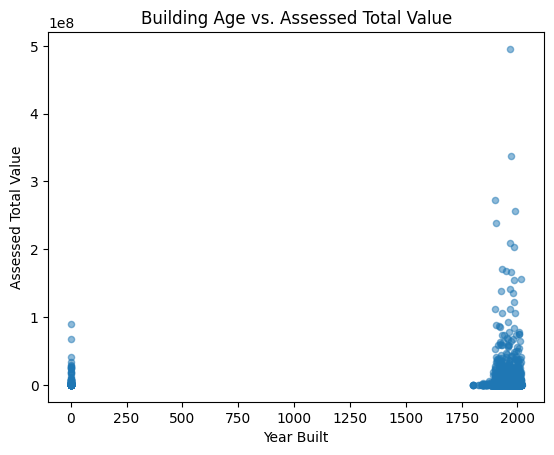

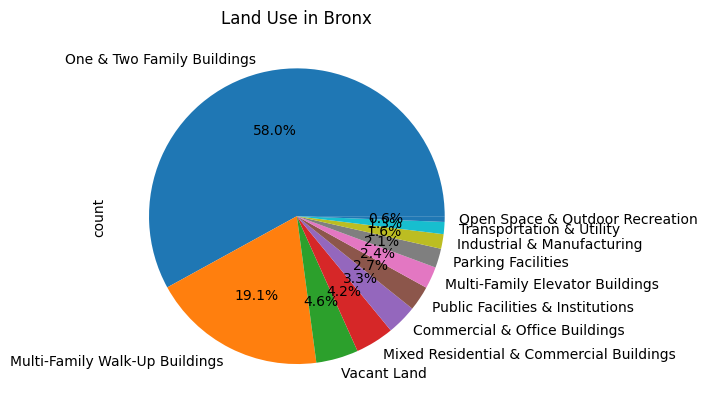

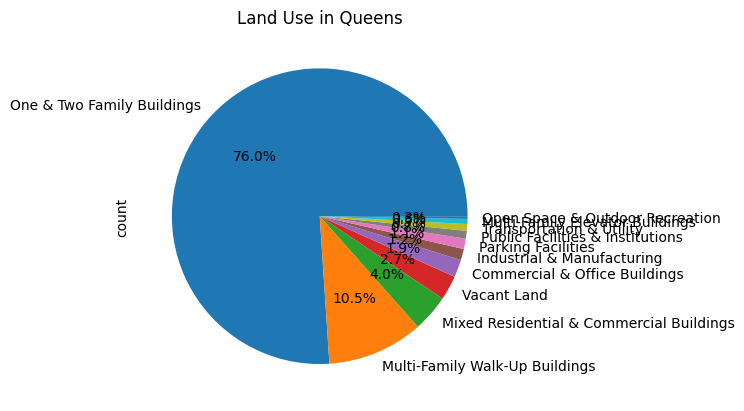

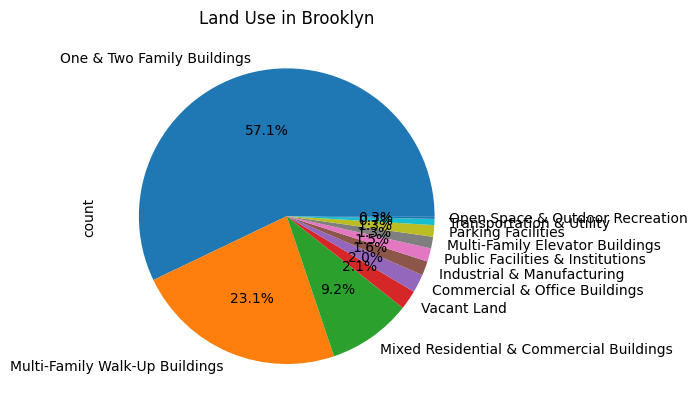

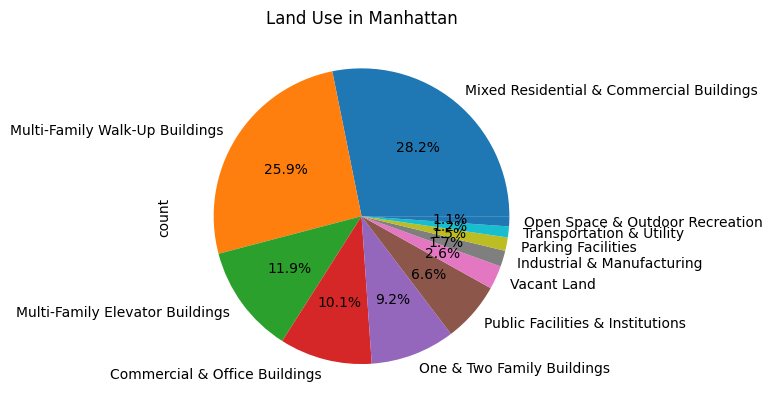

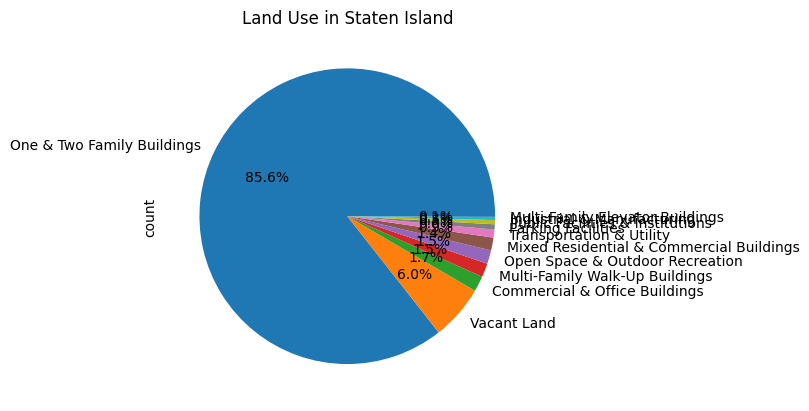

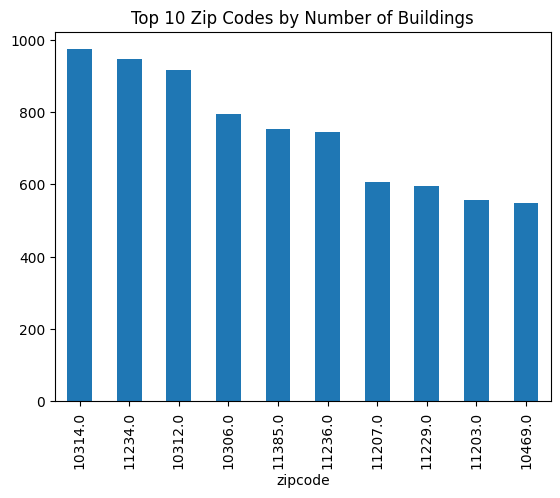

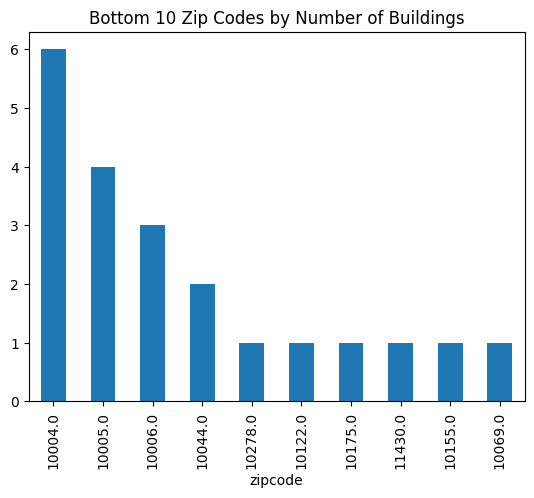

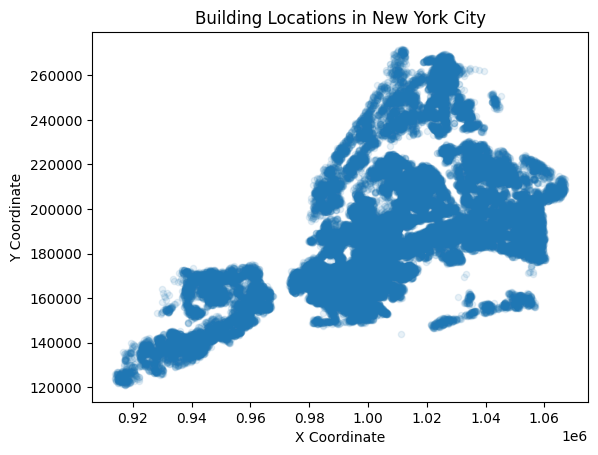

In [16]:
# YOUR CODE HERE:
# How does price vary with age? (scatter of age vs. price)
df.plot.scatter(x='yearbuilt', y='assesstot', alpha=0.5)
plt.title('Building Age vs. Assessed Total Value')
plt.xlabel('Year Built')
plt.ylabel('Assessed Total Value')
plt.show()


# Does the breakdown of building types differ between boroughs? (pie chart of landuse)
for borough in df['borough'].unique():
    borough_data = df[df['borough'] == borough]
    borough_data['landuse'].value_counts().plot.pie(autopct='%1.1f%%', title=f'Land Use in {borough}')
    plt.show()

# Which zip codes have most and fewest buildings?
zip_counts = df['zipcode'].value_counts()
zip_counts.head(10).plot.bar(title='Top 10 Zip Codes by Number of Buildings')
plt.show()
zip_counts.tail(10).plot.bar(title='Bottom 10 Zip Codes by Number of Buildings')
plt.show()



# Where are the buildings located? (scatter plot of xcoord and ycoord)
df.plot.scatter(x='xcoord', y='ycoord', alpha=0.1)
plt.title('Building Locations in New York City')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

#### BONUS ADVANCED QUESTION!
Impute missing values for year_built using a custom strategy:
* Replace all NaNs with the mean year_built for buildings of the same `landuse`.
* More advanced version: replace all NaNs with mean `year_built` for buildings of the same `landuse` in the same borough. (eg. multi-family buildings in Brooklyn)

In [17]:
# Strategy 1: Replace NaNs with mean year_built for buildings of the same landuse
df['yearbuilt_imputed_1'] = df.groupby('landuse')['yearbuilt'].transform(lambda x: x.fillna(x.mean()))

# Strategy 2: Replace NaNs with mean year_built for buildings of the same landuse in the same borough
df['yearbuilt_imputed_2'] = df.groupby(['borough', 'landuse'])['yearbuilt'].transform(lambda x: x.fillna(x.mean()))

# Check the results
print("Original 'yearbuilt' null count:", df['yearbuilt'].isnull().sum())
print("'yearbuilt_imputed_1' null count:", df['yearbuilt_imputed_1'].isnull().sum())
print("'yearbuilt_imputed_2' null count:", df['yearbuilt_imputed_2'].isnull().sum())

# Display some rows to compare
print(df[['borough', 'landuse', 'yearbuilt', 'yearbuilt_imputed_1', 'yearbuilt_imputed_2']].head(10))



Original 'yearbuilt' null count: 20
'yearbuilt_imputed_1' null count: 134
'yearbuilt_imputed_2' null count: 134
         borough                         landuse  yearbuilt  \
0          Bronx        Transportation & Utility        0.0   
1         Queens      One & Two Family Buildings     1925.0   
2       Brooklyn      One & Two Family Buildings     1920.0   
3      Manhattan  Multi-Family Walk-Up Buildings     1900.0   
4         Queens      One & Two Family Buildings     1901.0   
5       Brooklyn      One & Two Family Buildings     1905.0   
6  Staten Island      One & Two Family Buildings     1984.0   
7          Bronx  Multi-Family Walk-Up Buildings     1923.0   
8  Staten Island      One & Two Family Buildings     1995.0   
9         Queens      One & Two Family Buildings     1955.0   

   yearbuilt_imputed_1  yearbuilt_imputed_2  
0                  0.0                  0.0  
1               1925.0               1925.0  
2               1920.0               1920.0  
3         